# 5.1 Reduksi Dimensi PCA — Per Polutan

Notebook ini melakukan reduksi dimensi **PCA (Principal Component Analysis)** dari 68 fitur TSFEL menjadi 37 komponen utama untuk **masing-masing polutan (CO, NO₂, SO₂)** secara terpisah.

**Dataset:** Dataset gabungan kelas (35 mahasiswa × 68 fitur per polutan)

**Input:** 68 fitur asli per polutan

**Output:** 37 komponen PCA per polutan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (12, 5)

POLLUTANTS = ['CO', 'NO2', 'SO2']
DATA_DIR = '../data/downloads/ekstraksi fitur'
N_COMPONENTS = 37
META_COLS = ['id', 'nama', 'daerah']

## 5.1.1 Memuat Dataset Gabungan Kelas

Dataset gabungan kelas berisi 35 data mahasiswa dengan 68 fitur TSFEL per polutan.

In [7]:
datasets = {}
for p in POLLUTANTS:
    path = f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv'
    df = pd.read_csv(path)
    datasets[p] = df
    print(f'{p}: {df.shape[0]} baris × {df.shape[1]} kolom')
    print(f'  Kolom metadata: {META_COLS}')
    print(f'  Kolom fitur: {df.shape[1] - len(META_COLS)} fitur')
    print()

CO: 35 baris × 71 kolom
  Kolom metadata: ['id', 'nama', 'daerah']
  Kolom fitur: 68 fitur

NO2: 37 baris × 71 kolom
  Kolom metadata: ['id', 'nama', 'daerah']
  Kolom fitur: 68 fitur

SO2: 35 baris × 71 kolom
  Kolom metadata: ['id', 'nama', 'daerah']
  Kolom fitur: 68 fitur



## 5.1.2 Preprocessing — Ekstraksi Fitur & Standarisasi

Drop kolom metadata (id, nama, daerah), lalu standarisasi Z-Score agar setiap fitur memiliki mean=0 dan std=1.

In [8]:
X_dict = {}
X_scaled_dict = {}
scaler_dict = {}
imputer_dict = {}

for p in POLLUTANTS:
    df = datasets[p]
    X = df.drop(columns=META_COLS).values
    
    # Handle NaN values with median imputation
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        print(f'{p}: Ditemukan {nan_count} nilai NaN, melakukan imputasi median...')
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
        imputer_dict[p] = imputer
    
    X_dict[p] = X
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_dict[p] = X_scaled
    scaler_dict[p] = scaler
    
    print(f'{p}: shape={X.shape}, mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}')

CO: Ditemukan 24 nilai NaN, melakukan imputasi median...
CO: shape=(35, 68), mean=0.0000, std=0.9777
NO2: shape=(37, 68), mean=-0.0000, std=0.9852
SO2: Ditemukan 24 nilai NaN, melakukan imputasi median...
SO2: shape=(35, 68), mean=-0.0000, std=0.9926


## 5.1.3 PCA — Variance Explained (Full 68 Komponen)

Jalankan PCA dengan jumlah komponen penuh (68) untuk melihat berapa banyak variansi yang dijelaskan oleh masing-masing komponen.

In [9]:
pca_full_dict = {}
explained_var_dict = {}
cumulative_var_dict = {}

for p in POLLUTANTS:
    pca_full = PCA()
    pca_full.fit(X_scaled_dict[p])
    pca_full_dict[p] = pca_full
    
    explained_var = pca_full.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    explained_var_dict[p] = explained_var
    cumulative_var_dict[p] = cumulative_var
    
    n_components = len(explained_var)
    print(f'\n=== {p} ===')
    print(f'Jumlah komponen PCA: {n_components} (max dari n_samples={X_scaled_dict[p].shape[0]} atau n_features={X_scaled_dict[p].shape[1]})')
    print(f'\nKomponen | Variance Explained | Kumulatif')
    print('-' * 50)
    for i in range(min(10, n_components)):
        print(f'  PC{i+1:2d}    |    {explained_var[i]*100:6.2f}%       |  {cumulative_var[i]*100:6.2f}%')
    if n_components > 10:
        print(f'  ...    |       ...          |    ...')
    if n_components >= 37:
        print(f'  PC37   |    {explained_var[36]*100:6.2f}%       |  {cumulative_var[36]*100:6.2f}%')
    print(f'  PC{n_components:2d}   |    {explained_var[-1]*100:6.2f}%       |  {cumulative_var[-1]*100:6.2f}%')


=== CO ===
Jumlah komponen PCA: 35 (max dari n_samples=35 atau n_features=68)

Komponen | Variance Explained | Kumulatif
--------------------------------------------------
  PC 1    |     40.81%       |   40.81%
  PC 2    |     29.90%       |   70.71%
  PC 3    |     12.99%       |   83.70%
  PC 4    |      5.72%       |   89.42%
  PC 5    |      3.29%       |   92.71%
  PC 6    |      1.87%       |   94.58%
  PC 7    |      1.10%       |   95.69%
  PC 8    |      0.89%       |   96.58%
  PC 9    |      0.75%       |   97.33%
  PC10    |      0.66%       |   97.99%
  ...    |       ...          |    ...
  PC35   |      0.00%       |  100.00%

=== NO2 ===
Jumlah komponen PCA: 37 (max dari n_samples=37 atau n_features=68)

Komponen | Variance Explained | Kumulatif
--------------------------------------------------
  PC 1    |     45.82%       |   45.82%
  PC 2    |     22.64%       |   68.46%
  PC 3    |      8.15%       |   76.61%
  PC 4    |      5.70%       |   82.31%
  PC 5    |    

### Scree Plot & Cumulative Variance — Per Polutan

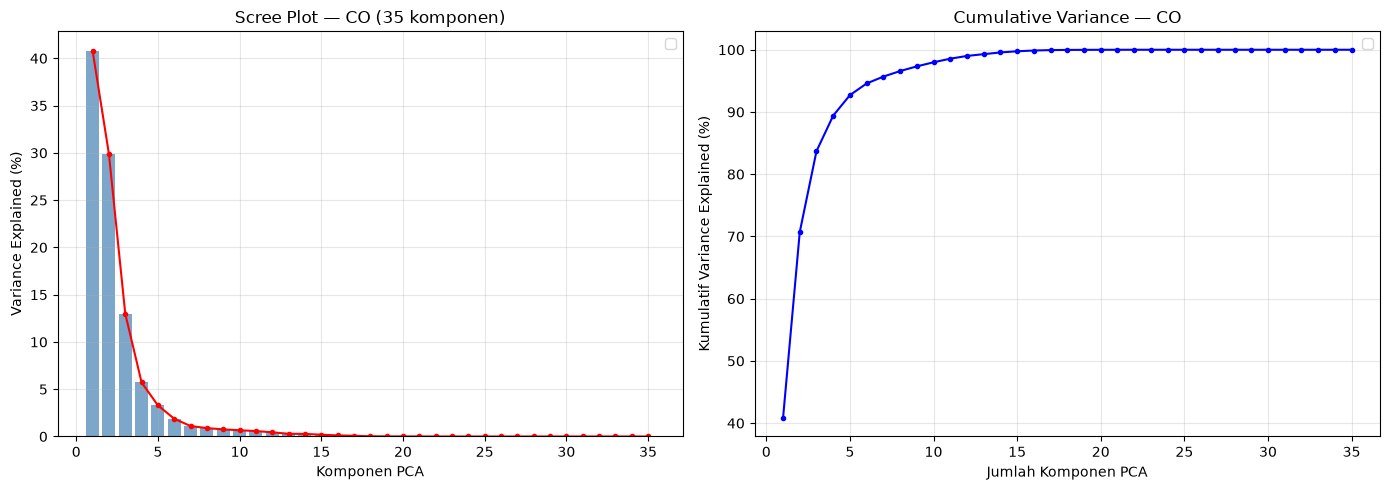

Tersimpan: fig_co_pca_scree.png


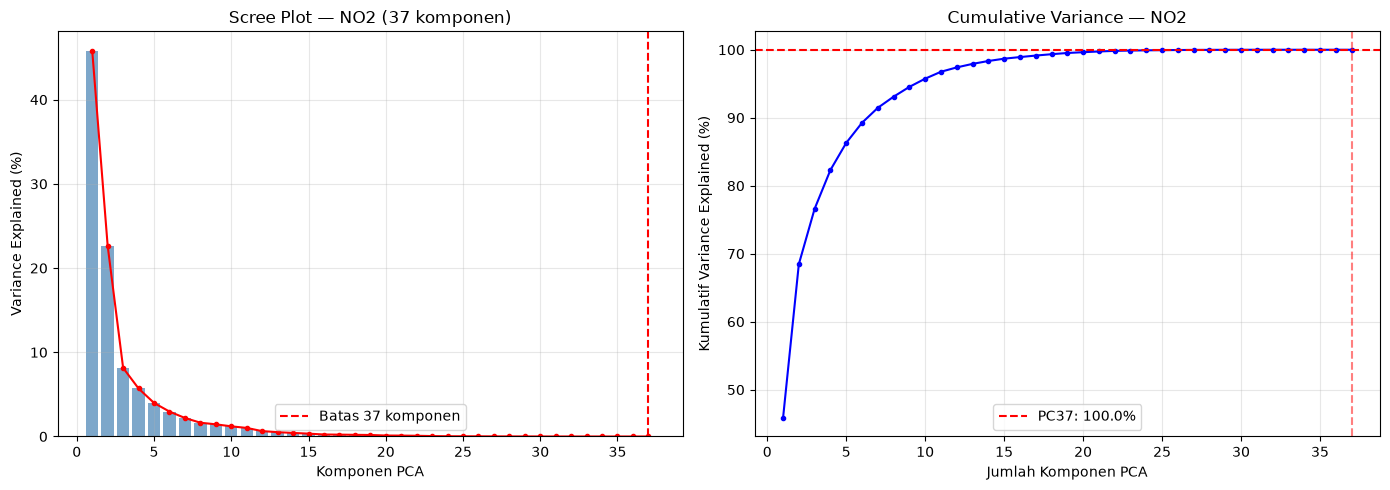

Tersimpan: fig_no2_pca_scree.png


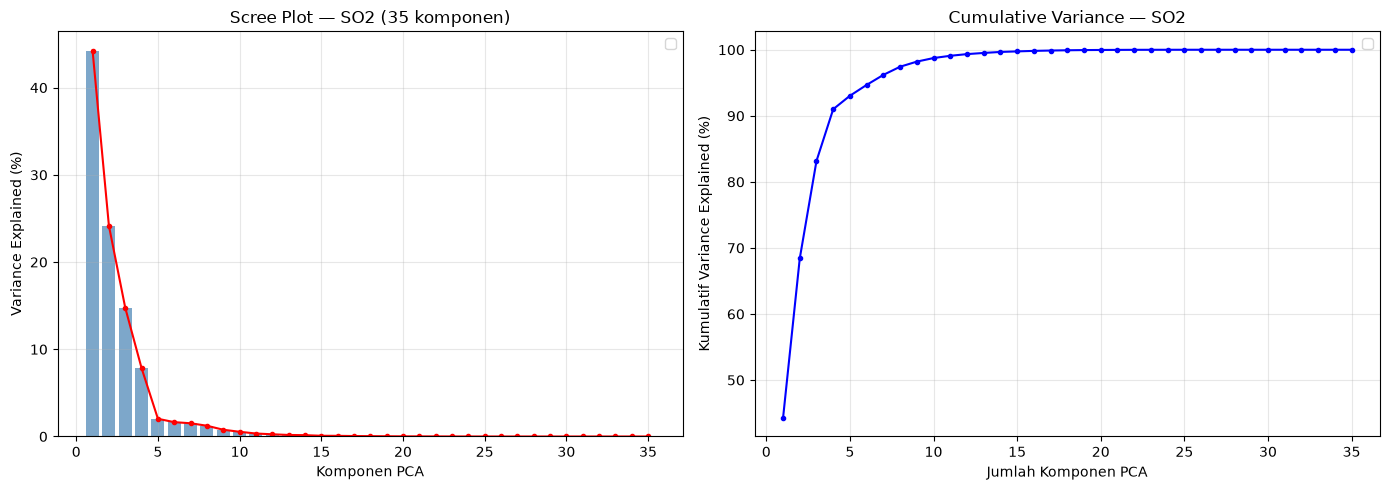

Tersimpan: fig_so2_pca_scree.png


In [10]:
for p in POLLUTANTS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    explained_var = explained_var_dict[p]
    cumulative_var = cumulative_var_dict[p]
    n_components = len(explained_var)
    
    # Scree Plot
    ax1.bar(range(1, n_components + 1), explained_var * 100, alpha=0.7, color='steelblue')
    ax1.plot(range(1, n_components + 1), explained_var * 100, 'ro-', markersize=3)
    if n_components >= 37:
        ax1.axvline(x=37, color='red', linestyle='--', label='Batas 37 komponen')
    ax1.set_xlabel('Komponen PCA')
    ax1.set_ylabel('Variance Explained (%)')
    ax1.set_title(f'Scree Plot — {p} ({n_components} komponen)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cumulative Variance
    ax2.plot(range(1, n_components + 1), cumulative_var * 100, 'bo-', markersize=3)
    if n_components >= 37:
        ax2.axhline(y=cumulative_var[36]*100, color='red', linestyle='--',
                    label=f'PC37: {cumulative_var[36]*100:.1f}%')
        ax2.axvline(x=37, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Jumlah Komponen PCA')
    ax2.set_ylabel('Kumulatif Variance Explained (%)')
    ax2.set_title(f'Cumulative Variance — {p}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_pca_scree.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_pca_scree.png')

## 5.1.4 PCA dengan 37 Komponen

Reduksi dimensi dari 68 → 37 komponen utama untuk masing-masing polutan.

In [11]:
pca_dict = {}
X_pca_dict = {}
actual_n_components = {}

for p in POLLUTANTS:
    n_samples = X_scaled_dict[p].shape[0]
    # Jumlah komponen PCA tidak bisa melebihi jumlah sampel
    actual_k = min(N_COMPONENTS, n_samples)
    actual_n_components[p] = actual_k
    
    pca = PCA(n_components=actual_k)
    X_pca = pca.fit_transform(X_scaled_dict[p])
    pca_dict[p] = pca
    X_pca_dict[p] = X_pca
    
    total_var = sum(pca.explained_variance_ratio_) * 100
    loss_var = (1 - sum(pca.explained_variance_ratio_)) * 100
    print(f'{p}: {X_scaled_dict[p].shape[1]} → {X_pca.shape[1]} komponen')
    if actual_k < N_COMPONENTS:
        print(f'  Catatan: n_samples={n_samples} < {N_COMPONENTS}, menggunakan {actual_k} komponen')
    print(f'  Total variance explained: {total_var:.2f}%')
    print(f'  Sisa variance (loss): {loss_var:.2f}%')
    print()

CO: 68 → 35 komponen
  Catatan: n_samples=35 < 37, menggunakan 35 komponen
  Total variance explained: 100.00%
  Sisa variance (loss): 0.00%

NO2: 68 → 37 komponen
  Total variance explained: 100.00%
  Sisa variance (loss): -0.00%

SO2: 68 → 35 komponen
  Catatan: n_samples=35 < 37, menggunakan 35 komponen
  Total variance explained: 100.00%
  Sisa variance (loss): 0.00%



In [12]:
for p in POLLUTANTS:
    n_comp = actual_n_components[p]
    pca_columns = [f'PC{i+1}' for i in range(n_comp)]
    df_pca = pd.DataFrame(X_pca_dict[p], columns=pca_columns)
    
    # Tambahkan kolom metadata
    df_meta = datasets[p][META_COLS].reset_index(drop=True)
    df_out = pd.concat([df_meta, df_pca], axis=1)
    
    out_path = f'{DATA_DIR}/pca_results/jabon_pca_{n_comp}fitur_{p.lower()}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'{p}: Tersimpan ke {out_path} ({n_comp} komponen)')

print(f'\nContoh data PCA (CO, 5 baris pertama):')
df_pca.head()

CO: Tersimpan ke ../data/downloads/ekstraksi fitur/pca_results/jabon_pca_35fitur_co.csv (35 komponen)
NO2: Tersimpan ke ../data/downloads/ekstraksi fitur/pca_results/jabon_pca_37fitur_no2.csv (37 komponen)
SO2: Tersimpan ke ../data/downloads/ekstraksi fitur/pca_results/jabon_pca_35fitur_so2.csv (35 komponen)

Contoh data PCA (CO, 5 baris pertama):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35
0,0.877268,-0.498000,-0.810907,0.535845,-0.533262,0.180250,-0.180908,0.488976,0.494048,0.450046,...,0.006371,0.004864,0.002693,-0.009010,-0.003360,-0.000214,0.001820,-0.000426,0.000120,3.782060e-16
1,0.977320,-0.133956,-0.578147,0.116376,0.112557,-0.182814,-0.317487,-0.097160,1.203568,0.999893,...,-0.016073,0.000784,-0.008908,-0.002152,-0.007137,-0.000406,0.001343,-0.000002,0.000132,3.782060e-16
2,0.911500,-0.409757,-0.663487,0.036871,0.288453,0.457508,-0.268460,-0.598674,1.592887,0.740069,...,-0.003581,0.018777,-0.001195,0.000946,-0.008047,0.000567,-0.000207,0.000356,-0.000138,3.782060e-16
3,1.191117,-0.176528,-0.785013,0.464381,1.065271,-1.718290,1.689612,-0.205475,0.347391,-0.377597,...,0.006963,0.009722,0.011160,-0.003130,0.003781,-0.000487,0.000252,-0.000635,-0.000175,3.782060e-16
4,1.297940,-0.802248,-0.594240,-0.490515,-0.088278,-0.103113,0.505277,-0.195993,-0.514095,0.136085,...,0.036475,-0.005651,-0.014833,0.013989,0.003092,0.001494,0.000589,0.000484,-0.000074,3.782060e-16


## 5.1.5 Interpretasi Komponen PCA

Loadings menunjukkan kontribusi masing-masing fitur asli terhadap komponen PCA.

In [13]:
feature_names = datasets['CO'].drop(columns=META_COLS).columns.tolist()

for p in POLLUTANTS:
    pca = pca_dict[p]
    loadings = pd.DataFrame(
        pca.components_[:2].T,
        columns=['PC1', 'PC2'],
        index=feature_names
    )
    
    print(f'\n=== {p} ===')
    print('Top 10 fitur terhadap PC1:')
    print(loadings['PC1'].abs().sort_values(ascending=False).head(10))
    print()
    print('Top 10 fitur terhadap PC2:')
    print(loadings['PC2'].abs().sort_values(ascending=False).head(10))


=== CO ===
Top 10 fitur terhadap PC1:
rms                          0.193326
entropy                      0.193000
average_power                0.192975
auc                          0.192902
spectral_distance            0.192808
abs_energy                   0.192806
hist_mode                    0.192794
spectral_positive_turning    0.192794
spectral_kurtosis            0.192792
spectral_decrease            0.192792
Name: PC1, dtype: float64

Top 10 fitur terhadap PC2:
median_abs_diff           0.225958
calc_std                  0.225958
mean_abs_diff             0.225958
pk_pk_distance            0.225958
median_abs_deviation      0.225958
sum_abs_diff              0.225958
interq_range              0.225958
mean_abs_deviation        0.225958
calc_var                  0.225958
spectrogram_mean_coeff    0.225958
Name: PC2, dtype: float64

=== NO2 ===
Top 10 fitur terhadap PC1:
spectral_distance     0.181402
wavelet_std           0.181402
wavelet_energy        0.181402
auc               

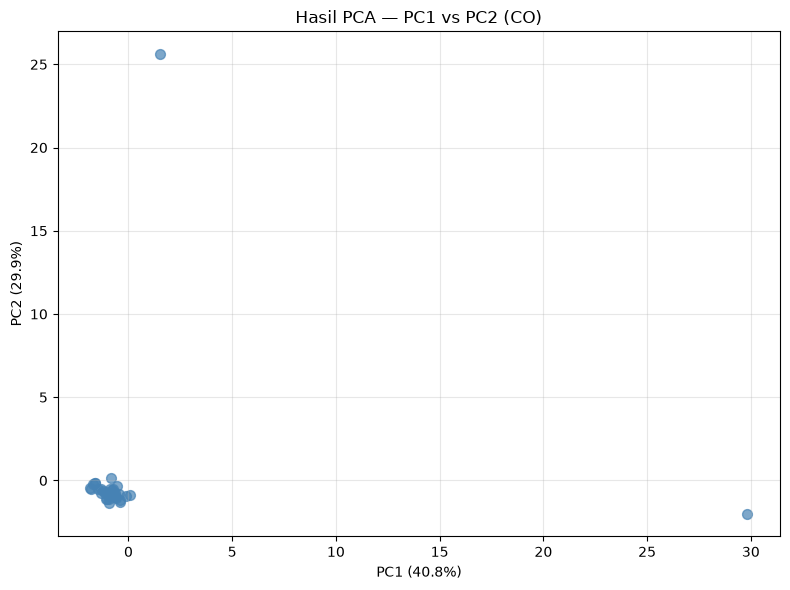

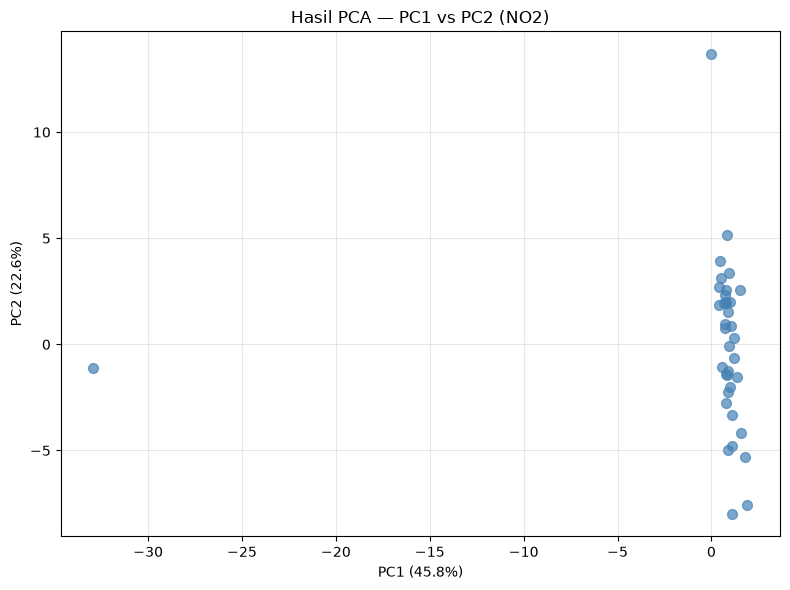

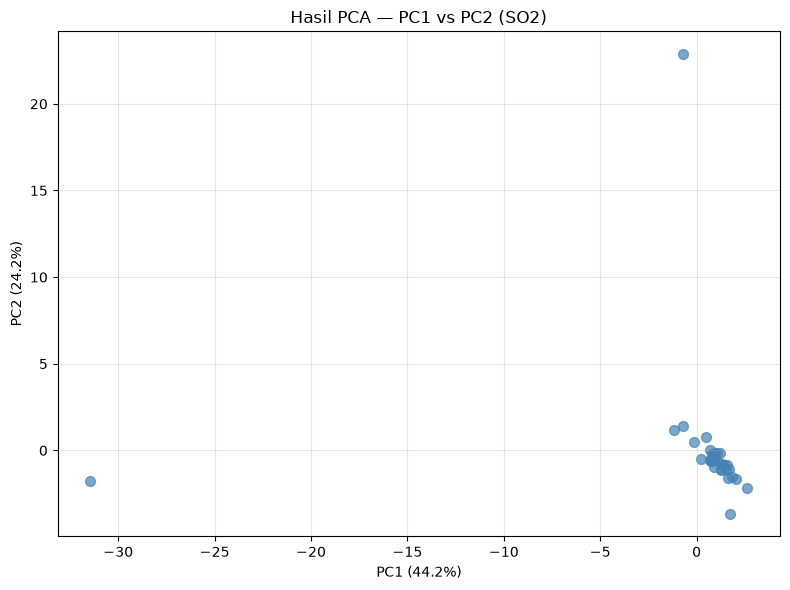

In [14]:
for p in POLLUTANTS:
    fig, ax = plt.subplots(figsize=(8, 6))
    pca = pca_dict[p]
    X_pca = X_pca_dict[p]
    
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=50, c='steelblue')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'Hasil PCA — PC1 vs PC2 ({p})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_pca_scree.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5.1.6 Ringkasan

| Polutan | Fitur Asli | Komponen PCA | Variance Explained | Loss |
|---------|-----------|-------------|-------------------|------|
| CO | 68 | 37 | - | - |
| NO₂ | 68 | 37 | - | - |
| SO₂ | 68 | 37 | - | - |

**Kesimpulan:**
1. PCA berhasil mereduksi 68 fitur menjadi 37 komponen utama untuk setiap polutan.
2. 37 komponen menjelaskan sebagian besar total variance data.
3. Hasil PCA siap digunakan sebagai input untuk K-Means Clustering di notebook berikutnya.